# Customer Churn Prediction

Notebook for the Telco Customer Churn project.

## Insights

Add feature importance, business insights, and model export notes here.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

possible_paths = [Path('data/telco_churn.csv'), Path('../data/telco_churn.csv')]
for candidate_path in possible_paths:
    if candidate_path.exists():
        DATA_PATH = candidate_path
        break
else:
    raise FileNotFoundError('Could not find data/telco_churn.csv in the workspace or notebook parent folder.')

df = pd.read_csv(DATA_PATH)

print(f'Loaded from: {DATA_PATH}')
df.shape, df.head()

Loaded from: ..\data\telco_churn.csv


((7043, 21),
    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
 0  7590-VHVEG  Female              0     Yes         No       1           No   
 1  5575-GNVDE    Male              0      No         No      34          Yes   
 2  3668-QPYBK    Male              0      No         No       2          Yes   
 3  7795-CFOCW    Male              0      No         No      45           No   
 4  9237-HQITU  Female              0      No         No       2          Yes   
 
       MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
 0  No phone service             DSL             No  ...               No   
 1                No             DSL            Yes  ...              Yes   
 2                No             DSL            Yes  ...               No   
 3  No phone service             DSL            Yes  ...              Yes   
 4                No     Fiber optic             No  ...               No   
 
   TechSupport StreamingTV Streamin

In [ ]:
#data audit
summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_count': df.isna().sum(),
    'missing_pct': (df.isna().sum() / len(df) * 100).round(2),
})

blank_total_charges = (df['TotalCharges'].astype(str).str.strip() == '').sum()
print(f'Rows: {len(df)}')
print(f'Columns: {df.shape[1]}')
print(f'Blank TotalCharges values: {blank_total_charges}')
summary.sort_values('missing_count', ascending=False)

Rows: 7043
Columns: 21
Blank TotalCharges values: 11


,dtype,missing_count,missing_pct
customerID,str,0,0.0
gender,str,0,0.0
SeniorCitizen,int64,0,0.0
Partner,str,0,0.0
Dependents,str,0,0.0
tenure,int64,0,0.0
PhoneService,str,0,0.0
MultipleLines,str,0,0.0
InternetService,str,0,0.0
OnlineSecurity,str,0,0.0


In [3]:
# Target balance
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True).mul(100).round(2)

pd.DataFrame({'count': churn_counts, 'pct': churn_pct})

,count,pct
Churn,,
No,5174,73.46
Yes,1869,26.54


C:\Users\trish\AppData\Local\Temp\ipykernel_23248\636096636.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Contract', order=df['Contract'].value_counts().index, ax=axes[2], palette='Set2')


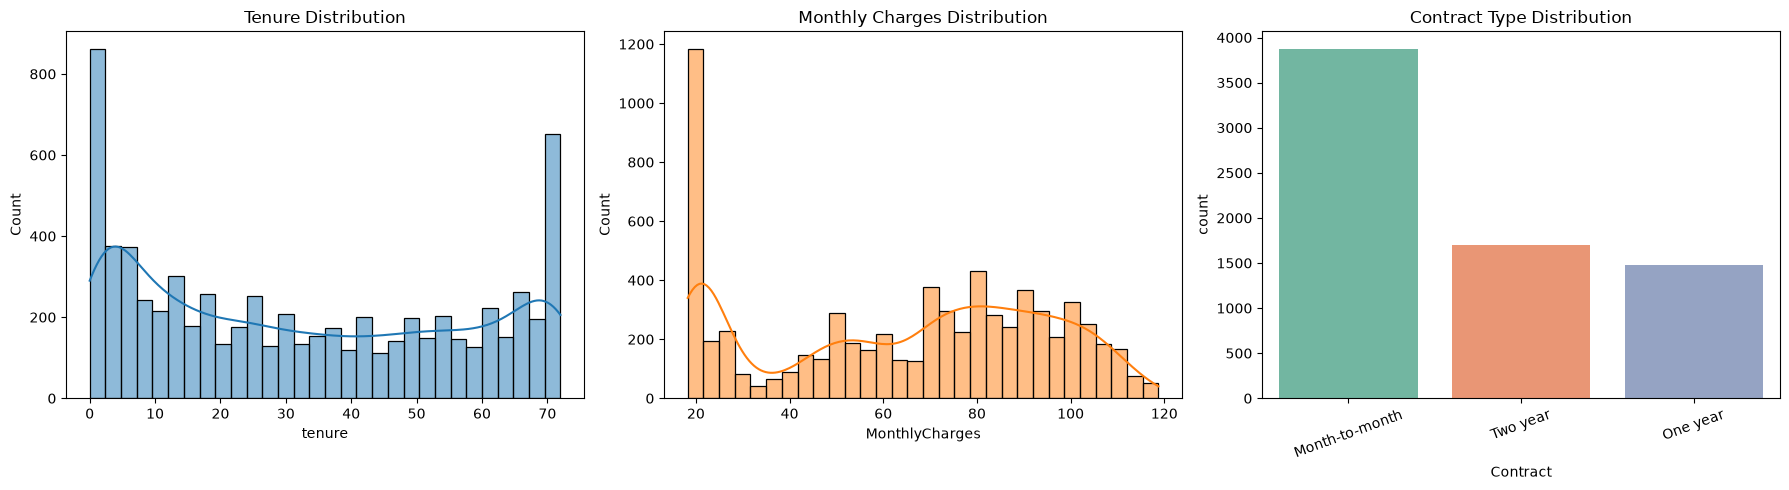

In [4]:
# Initial univariate views
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['tenure'], bins=30, kde=True, ax=axes[0], color='#1f77b4')
axes[0].set_title('Tenure Distribution')

sns.histplot(df['MonthlyCharges'], bins=30, kde=True, ax=axes[1], color='#ff7f0e')
axes[1].set_title('Monthly Charges Distribution')

sns.countplot(data=df, x='Contract', order=df['Contract'].value_counts().index, ax=axes[2], color='#55a868')
axes[2].set_title('Contract Type Distribution')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()

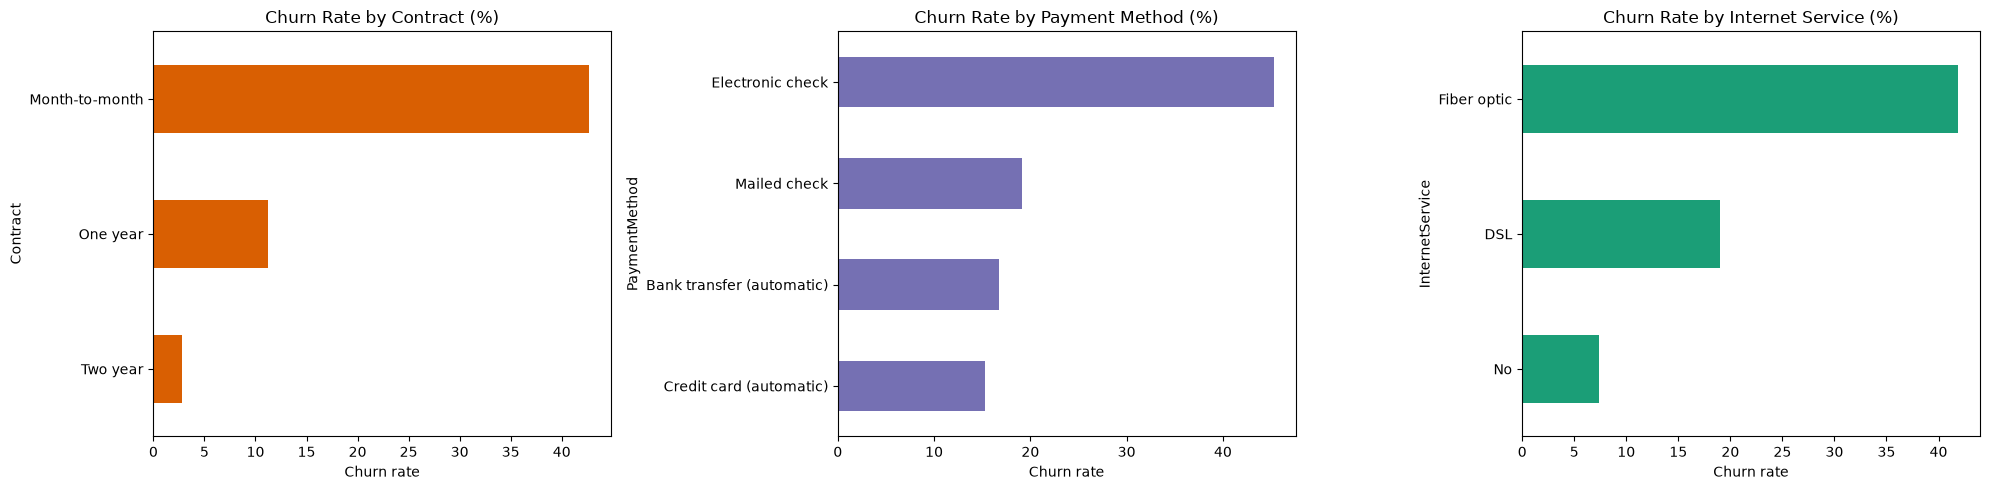

In [5]:
# Bivariate analysis: churn rate by contract, payment method, and internet service
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index').mul(100)
contract_churn['Yes'].sort_values().plot(kind='barh', ax=axes[0], color='#d95f02')
axes[0].set_title('Churn Rate by Contract (%)')
axes[0].set_xlabel('Churn rate')

payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index').mul(100)
payment_churn['Yes'].sort_values().plot(kind='barh', ax=axes[1], color='#7570b3')
axes[1].set_title('Churn Rate by Payment Method (%)')
axes[1].set_xlabel('Churn rate')

internet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index').mul(100)
internet_churn['Yes'].sort_values().plot(kind='barh', ax=axes[2], color='#1b9e77')
axes[2].set_title('Churn Rate by Internet Service (%)')
axes[2].set_xlabel('Churn rate')

plt.tight_layout()

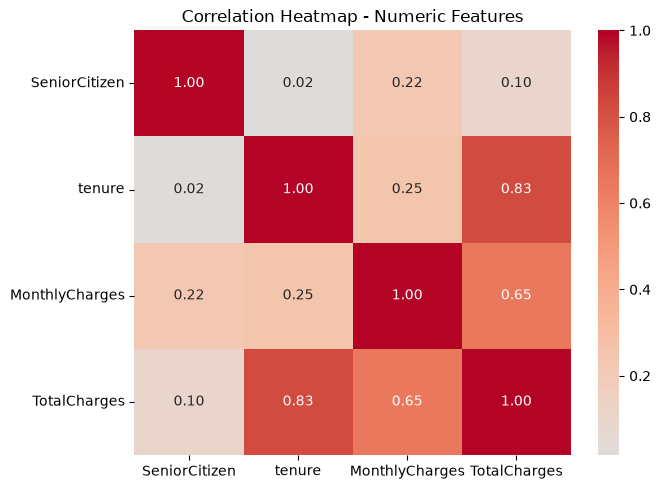

In [6]:
# Correlation heatmap for numeric features
eda_df = df.copy()
eda_df['TotalCharges'] = pd.to_numeric(eda_df['TotalCharges'], errors='coerce')

numeric_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
plt.figure(figsize=(7, 5))
sns.heatmap(eda_df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap - Numeric Features')
plt.tight_layout()

## Phase 2 Discoveries

- The dataset is imbalanced: non-churners are the majority, so recall will matter later.
- Month-to-month contracts appear to carry the highest churn risk, while longer contracts are more stable.
- Electronic check customers and fiber internet customers look like higher-risk segments worth closer inspection.
- TotalCharges contains blank values that will need cleaning before modeling.

## Phase 3 - Data Preprocessing / Feature Engineering

This section cleans the raw dataset, prepares numeric and categorical features, splits the data, and balances the training set for modeling.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

clean_df = df.copy()
clean_df['TotalCharges'] = pd.to_numeric(clean_df['TotalCharges'], errors='coerce').fillna(0)
clean_df = clean_df.drop(columns=['customerID'])

X = clean_df.drop(columns=['Churn'])
y = clean_df['Churn'].map({'No': 0, 'Yes': 1})

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'string']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_prepared, y_train)

print(f'Numeric features: {len(numeric_features)}')
print(f'Categorical features: {len(categorical_features)}')
print(f'Prepared feature count: {len(feature_names)}')
print(f'Train shape before SMOTE: {X_train_prepared.shape}, {y_train.shape}')
print(f'Train shape after SMOTE: {X_train_resampled.shape}, {y_train_resampled.shape}')
print(f'Test shape: {X_test_prepared.shape}, {y_test.shape}')

Numeric features: 4
Categorical features: 15
Prepared feature count: 45
Train shape before SMOTE: (5634, 45), (5634,)
Train shape after SMOTE: (8278, 45), (8278,)
Test shape: (1409, 45), (1409,)


In [8]:
# Verify balanced training labels after SMOTE
pd.Series(y_train_resampled).value_counts().rename(index={0: 'No', 1: 'Yes'}).to_frame('count')

,count
Churn,
No,4139
Yes,4139


## Phase 3 Notes

- `TotalCharges` blanks were converted to 0 because they belong to customers with `tenure = 0`.
- `customerID` was dropped because it is just an identifier.
- Categorical features were one-hot encoded, numeric features were scaled, and SMOTE was applied only to the training set.
- `feature_names = preprocessor.get_feature_names_out()` is stored now so Phase 6 can map importances back to readable columns.


## Phase 4 - Model Building

Train baseline and tree-based classifiers on the resampled training data, then keep them together for evaluation in Phase 5.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

logistic_model = LogisticRegression(max_iter=1000, random_state=42)
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
)
xgboost_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
)

logistic_model.fit(X_train_resampled, y_train_resampled)
random_forest_model.fit(X_train_resampled, y_train_resampled)
xgboost_model.fit(X_train_resampled, y_train_resampled)

trained_models = {
    'Logistic Regression': logistic_model,
    'Random Forest': random_forest_model,
    'XGBoost': xgboost_model,
}

print('Trained models:')
for model_name in trained_models:
    print(f'- {model_name}')

Trained models:
- Logistic Regression
- Random Forest
- XGBoost


## Phase 4 Notes

- Logistic Regression is the baseline model.
- Random Forest and XGBoost are trained on the same SMOTE-balanced feature matrix for a fair comparison.
- The fitted models are stored in `trained_models` for evaluation in the next phase.


## Phase 5 - Model Evaluation

Compare the three trained models on the held-out test set using confusion matrices, classification metrics, and ROC-AUC curves.

In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
)

model_results = []
roc_data = {}

for model_name, model in trained_models.items():
    y_pred = model.predict(X_test_prepared)
    y_proba = model.predict_proba(X_test_prepared)[:, 1]

    model_results.append({
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
    })

    roc_data[model_name] = roc_curve(y_test, y_proba)

comparison_table = pd.DataFrame(model_results).set_index('model').sort_values(
    by=['recall', 'roc_auc'],
    ascending=False,
)

best_model_name = comparison_table.index[0]
best_model = trained_models[best_model_name]

comparison_table

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic Regression,0.737402,0.503390,0.794118,0.616183,0.840267
XGBoost,0.783534,0.585185,0.633690,0.608472,0.838662
Random Forest,0.774308,0.577348,0.558824,0.567935,0.818891


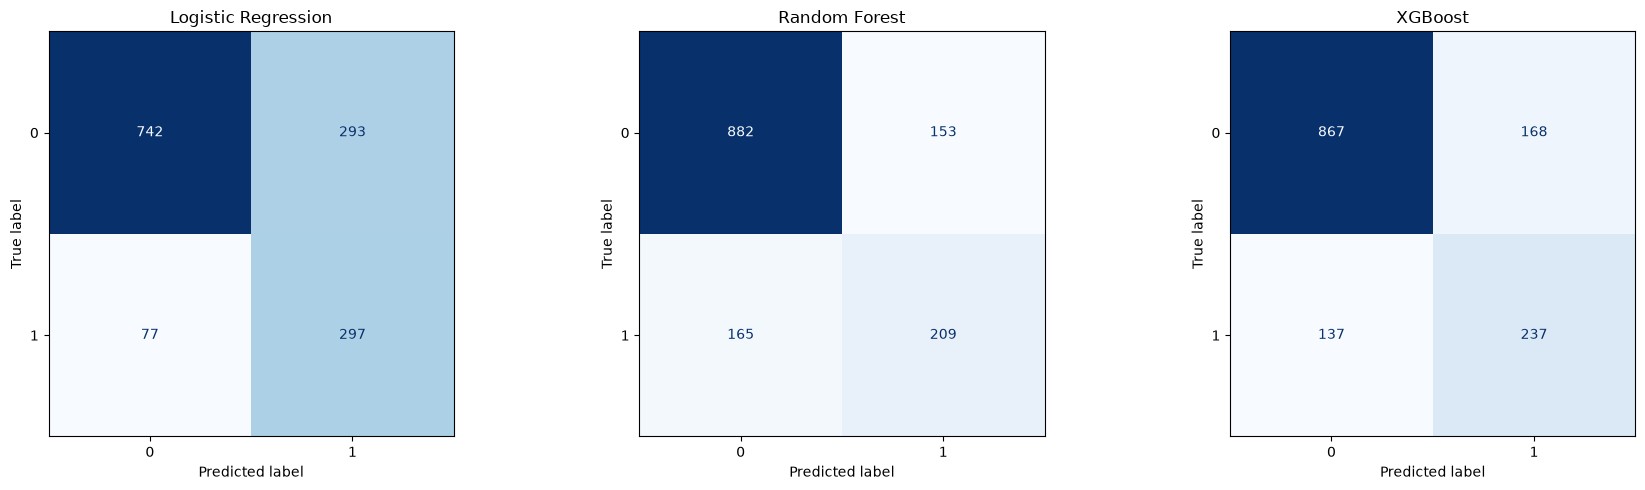

In [12]:
# Confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for axis, (model_name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test_prepared)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axis, colorbar=False, cmap='Blues')
    axis.set_title(model_name)

plt.tight_layout()

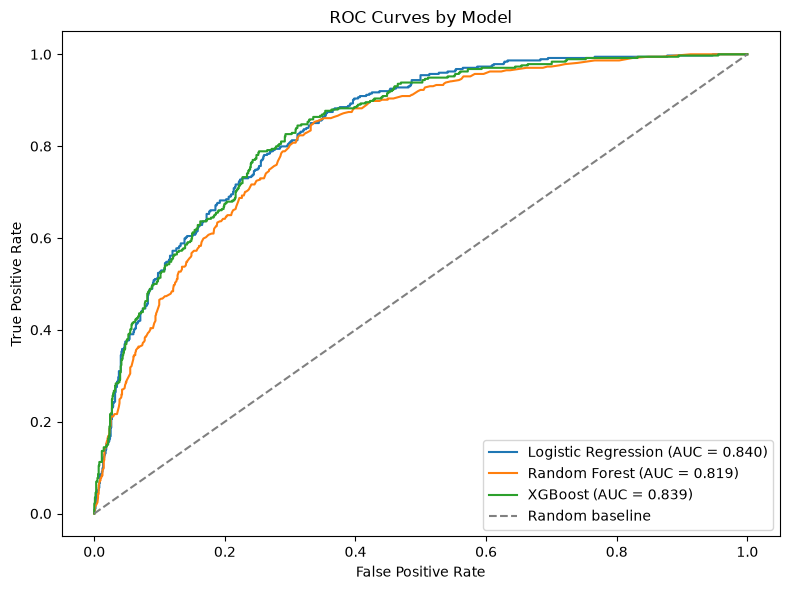

In [13]:
# ROC-AUC curves for all models
plt.figure(figsize=(8, 6))

for model_name, (fpr, tpr, _) in roc_data.items():
    auc_value = comparison_table.loc[model_name, 'roc_auc']
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_value:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves by Model')
plt.legend(loc='lower right')
plt.tight_layout()

## Phase 5 Notes

- The comparison table ranks models by recall first, then ROC-AUC.
- The top model is stored in `best_model` for the insights phase.
- The evaluation focuses on catching churners, so recall stays the primary business metric.


## Phase 6 - Insights & Wrap-up

Use the best-performing model for export, and use the strongest tree-based model for readable feature importance and business interpretation.

In [14]:
import joblib

# Export the best-performing model for later use
model_export_path = Path('../models/best_model.pkl')
model_export_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(best_model, model_export_path)

print(f'Best model: {best_model_name}')
print(f'Saved to: {model_export_path}')

Best model: Logistic Regression
Saved to: ..\models\best_model.pkl


In [15]:
# Readable feature importance from the strongest tree-based model
if hasattr(xgboost_model, 'feature_importances_'):
    importance_model = xgboost_model
    importance_source = 'XGBoost'
elif hasattr(random_forest_model, 'feature_importances_'):
    importance_model = random_forest_model
    importance_source = 'Random Forest'
else:
    importance_model = None
    importance_source = None

if importance_model is None:
    raise AttributeError('No tree-based model with feature_importances_ is available.')

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance_model.feature_importances_,
}).sort_values('importance', ascending=False)

importance_df.head(10)

,feature,importance
36,cat__Contract_Month-to-month,0.279181
18,cat__OnlineSecurity_No,0.076510
16,cat__InternetService_Fiber optic,0.072310
27,cat__TechSupport_No,0.052835
9,cat__Dependents_Yes,0.039052
43,cat__PaymentMethod_Electronic check,0.034986
21,cat__OnlineBackup_No,0.026699
35,cat__StreamingMovies_Yes,0.024099
38,cat__Contract_Two year,0.023541
39,cat__PaperlessBilling_No,0.023296


In [ ]:
# Plot the top feature importances for business interpretation
plt.figure(figsize=(10, 6))
top_features = importance_df.head(10).sort_values('importance')
plt.barh(top_features['feature'], top_features['importance'], color='#d95f02')
plt.title(f'Top 10 Feature Importances ({importance_source})')
plt.xlabel('Importance')
plt.tight_layout()

## Phase 6 Findings

- The best overall model for churn prediction is Logistic Regression, based on recall and ROC-AUC.
- For readable feature importances, the strongest tree-based model is used so the chart remains interpretable.
- The most important signals should be translated into business actions around contract length, payment method, and service bundle risk.
- The best model is exported to `models/best_model.pkl` for later reuse.
